# Feature Engineering

Notebook 00 produced `master_raw.csv`; Notebook 01 (EDA) showed *when* and *how* students engage matters as much as raw click totals. Here we turn raw columns into **17 behavioral features** for unsupervised clustering.

Every feature choice is grounded in EDA numbers (e.g. missing rate Fail **36.4%** vs Distinction **3.4%**, withdrawn late-week clicks **≈0.4** vs pass **≈56**). We save `master_features.csv`, `X_scaled.npy` (for clustering), and PCA outputs for visualization only.

> **Note on feature count:** The original project plan outlined 20 candidate features. After EDA, we reduced this to **17** by:
> - Keeping only `total_clicks_log` and `active_day_rate` from the click-volume family ,EDA showed `total_clicks`, `active_days`, `clicks_per_day`, and `active_day_rate` at |r| = 0.83–1.00.
> - Dropping `weekly_click_std_log` (r = 0.96 with `total_clicks_log`).
> - Excluding demographic covariates (`age_band`, `imd_band`, `disability`) from **X**.
>
> Fewer, non-redundant features give more meaningful Euclidean distances in K-Means. All seven modules stay in the dataset; rates use **`module_length` normalization** (`clicks_per_day`, `active_day_rate`) so presentations of different lengths are comparable.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
RAW = ROOT / "data" / "raw"
MODELS = ROOT / "models"
FIGURES = ROOT / "figures" / "features"
MODELS.mkdir(exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib
import src.features as features_mod
importlib.reload(features_mod)

from src.features import (
    FEATURE_COLS,
    META_COLS,
    WEEK_COLS,
    compute_group_a,
    compute_group_b,
    compute_group_c,
    compute_group_d,
    compute_group_e,
    compute_score_trend,
    scale_features,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = {
    "Distinction": "#1a6b5a",
    "Pass": "#c47a1e",
    "Fail": "#b84038",
    "Withdrawn": "#1e3a6e",
}
print(f"ROOT: {ROOT}")
print(f"Features to build: {len(FEATURE_COLS)}")


ROOT: D:\Ensia\3rd year\Afaf\S2\Machine Learning\project
Features to build: 17



We load `master_raw.csv` (**32,593** rows × **68** columns) from notebook 00 and the raw assessment files needed later for chronological **score_trend_slope**. We keep a working copy `df` and add feature columns group by group.



In [2]:
df = pd.read_csv(PROCESSED / "master_raw.csv")
assert df.shape[0] == 32_593, f"Expected 32593 rows, got {df.shape[0]}"
print(f"master_raw: {df.shape[0]:,} rows × {df.shape[1]} columns")

sa_path = RAW / "studentAssessment.csv"
assess_path = RAW / "assessments.csv"
assert sa_path.exists() and assess_path.exists(), "Raw assessment CSVs missing in data/raw/"
print("Raw assessment files found.")


master_raw: 32,593 rows × 68 columns
Raw assessment files found.


**Interpretation**

The table has **32,593** registrations and **68** columns (same `master_raw.csv` as notebooks 00–01, including `missing_rate`). Assessment files are present for chronological **score_trend_slope**.


## Core principle

Two students can share the same `total_clicks` and `avg_score` yet behave differently depending on **when** they clicked and whether they submitted work. EDA gave Pearson **r ≈ 0.48** between `clicks_per_day` and `avg_score` — useful but not enough alone. The features below capture timing, activity type, and assessment discipline that a single average hides.


## Group A Engagement volume (2 features)

EDA showed `total_clicks`, `active_days`, `clicks_per_day`, and `active_day_rate` correlate at **|r| ≈ 0.83–1.00**. We keep only **log volume** and **active_day_rate**. **10.3%** of students had zero clicks (confirmed real disengagement); `log1p(0) = 0` places them at the bottom without imputing the mean.


In [3]:
df = compute_group_a(df)
cols_a = ["total_clicks_log", "active_day_rate"]
print(df[cols_a].describe().round(3))
zero_log = (df["total_clicks_log"] == 0).sum()
print(f"Students with total_clicks_log == 0: {zero_log:,} ({zero_log/len(df)*100:.1f}%)")


       total_clicks_log  active_day_rate
count         32593.000        32593.000
mean              5.706            0.217
std               2.450            0.213
min               0.000            0.000
25%               4.963            0.041
50%               6.402            0.156
75%               7.369            0.336
max              10.092            1.073
Students with total_clicks_log == 0: 3,365 (10.3%)


**Interpretation**

**3,365** students (10.3%) have `total_clicks_log == 0` — matching EDA’s **10.3%** zero-click rate. Mean `active_day_rate` is **0.217** (active days ÷ `module_length`, median length **262** days in this dataset). That keeps withdrawn-type profiles low without keeping four redundant click columns (EDA |r|≈0.83–1.00).


## Group B Temporal pattern (5 features)

The temporal heatmap was the clearest EDA view: **withdrawn** late-week activity **≈0.4** clicks vs **≈56** for **Pass**. We build ratios over the module thirds, final-week cramming, **click_trend_slope** (OLS on weekly clicks — negative slope = fading engagement), and **last_active_day_norm** relative to module length.



In [4]:
df = compute_group_b(df)
cols_b = [
    "early_click_ratio", "late_click_ratio", "click_in_final_week_ratio",
    "last_active_day_norm",
]
print(df[cols_b].describe().round(3))
late_lm = (df["late_click_ratio"] > 0.5).sum()
print(f"late_click_ratio > 0.5 (Last-Minute candidates): {late_lm:,} ({late_lm/len(df)*100:.1f}%)")



       early_click_ratio  late_click_ratio  click_in_final_week_ratio  \
count          32593.000         32593.000                  32593.000   
mean               0.443             0.168                      0.014   
std                0.299             0.187                      0.044   
min                0.000             0.000                      0.000   
25%                0.245             0.000                      0.000   
50%                0.401             0.130                      0.000   
75%                0.644             0.291                      0.006   
max                1.000             1.000                      1.000   

       last_active_day_norm  
count             32593.000  
mean                  0.622  
std                   0.391  
min                   0.000  
25%                   0.190  
50%                   0.873  
75%                   0.959  
max                   1.000  
late_click_ratio > 0.5 (Last-Minute candidates): 1,847 (5.7%)


**Interpretation**

**1,847** students (5.7%) have `late_click_ratio > 0.5` — deadline-heavy learners. We dropped `weekly_click_std_log` from the final matrix because it correlated **0.96** with `total_clicks_log` (same EDA redundancy issue). Low `last_active_day_norm` still marks students who stopped accessing the VLE long before the module ended.


### Group B click_trend_slope

We fit `linregress` on weekly clicks (weeks within `module_length // 7`, capped at 34 week columns). Fewer than three non-zero weeks → slope **0**. Slopes are clipped at the **1st–99th** percentile to limit extreme outliers.


In [5]:
# Re-run slope with progress (compute_group_b already set click_trend_slope)
print(df["click_trend_slope"].describe().round(4))
neg = (df["click_trend_slope"] < 0).sum()
print(f"Negative slope (disengaging trend): {neg:,} ({neg/len(df)*100:.1f}%)")
print(f"EDA at-risk share (Withdrawn+Fail): {(df.final_result.isin(['Withdrawn','Fail'])).mean()*100:.1f}%")


count    32593.0000
mean        -1.2558
std          4.4801
min        -26.0010
25%         -1.6579
50%         -0.2000
75%          0.0897
max          9.5287
Name: click_trend_slope, dtype: float64
Negative slope (disengaging trend): 17,748 (54.5%)
EDA at-risk share (Withdrawn+Fail): 52.8%


**Interpretation**

**17,748** students (54.5%) have a negative `click_trend_slope` — fading weekly engagement. EDA at-risk outcomes (Fail + Withdrawn) were **52.8%**; the slope is not a perfect match but captures the heatmap fade pattern. Percentile clipping limits extreme slopes dominating K-Means distance.


## Group C Activity type quality (2 features)

Quiz/forum means rose from **Withdrawn (48 / 66)** to **Distinction (463 / 625)** in EDA; resource clicks stayed flat (**13–59**). We use **active_engagement_ratio** = (quiz+forum)/total and **quiz_click_ratio** only — no separate forum or resource ratios.


In [6]:
df = compute_group_c(df)
print(df[["active_engagement_ratio", "quiz_click_ratio"]].describe().round(3))
zero_active = (df["active_engagement_ratio"] == 0).sum()
print(f"active_engagement_ratio == 0: {zero_active:,} ({zero_active/len(df)*100:.1f}%)")


       active_engagement_ratio  quiz_click_ratio
count                32593.000         32593.000
mean                     0.300             0.143
std                      0.225             0.184
min                      0.000             0.000
25%                      0.117             0.000
50%                      0.282             0.073
75%                      0.460             0.222
max                      1.000             0.962
active_engagement_ratio == 0: 5,343 (16.4%)


**Interpretation**

**5,343** students (16.4%) have `active_engagement_ratio == 0` (no quiz or forum clicks relative to total). Mean ratio is **0.300**; EDA raw quiz counts still rose from Withdrawn (~48) to Distinction (~463) — ratios preserve order but compress scale.


## Group D  Assessment behaviour (5 features)

EDA flagged **missing_submission_rate** as the strongest single risk signal (**Fail 36.4%**, **Withdrawn 30.1%** vs **Distinction 3.4%**). We add **weighted_avg_score**, **score_consistency** (from `score_std`), **score_trend_slope** from raw chronological submissions, and **submission_timing** (mean delay vs deadline).


In [7]:
df["weighted_avg_score"] = df["avg_score"].fillna(0.0)
std = df["score_std"]
df["score_consistency"] = np.where(std.notna() & (std > 0), 1 / (1 + std), 0.5)
print(df[["weighted_avg_score", "score_consistency"]].describe().round(3))
zero_score = (df["weighted_avg_score"] == 0).sum()
print(f"weighted_avg_score == 0: {zero_score:,} ({zero_score/len(df)*100:.1f}%)")


       weighted_avg_score  score_consistency
count           32593.000          32593.000
mean               50.187              0.217
std                34.912              0.193
min                 0.000              0.014
25%                 0.000              0.064
50%                63.800              0.108
75%                79.000              0.500
max               100.000              0.691
weighted_avg_score == 0: 9,445 (29.0%)


**Interpretation**

**9,445** students (29.0%) have `weighted_avg_score == 0` (no gradable submissions). Mean `score_consistency` near **1** means stable marks across submitted assessments; lower values mean volatile score paths.


### Group D score_trend_slope from raw assessments

`master_raw` only stores averages. We reload **studentAssessment.csv**, drop **is_banked == 1**, sort by `date_submitted`, and regress score vs submission order per registration.


In [8]:
score_trend = compute_score_trend(sa_path, assess_path)
print(f"score_trend rows: {len(score_trend):,}")
print(score_trend["score_trend_slope"].describe().round(4))
decline = (score_trend["score_trend_slope"] < 0).sum()
print(f"Declining score trend: {decline:,} ({decline/len(score_trend)*100:.1f}%)")


score_trend rows: 25,559
count    25559.0000
mean        -1.2276
std          7.1688
min        -30.0000
25%         -2.9881
50%         -0.3030
75%          0.7976
max         25.5000
Name: score_trend_slope, dtype: float64
Declining score trend: 13,887 (54.3%)


**Interpretation**

**13,887** of **25,559** students with score-trend rows (54.3%) show a declining chronological score slope. Registrations without ≥2 submissions stay at **0** by rule — this is separate from the static average in `master_raw`.


In [9]:
df = compute_group_d(df, score_trend)
print(df[["missing_submission_rate", "submission_timing"]].describe().round(3))
print("\nMean missing_submission_rate (%) by outcome:")
print((df.groupby("final_result")["missing_submission_rate"].mean() * 100).round(1))
print("\nEDA check — raw avg_submission_delay (NaN excluded by pandas mean):")
print(df.groupby("final_result")["avg_submission_delay"].mean().round(1))
print("\nFeature submission_timing (mean delay among submitters for non-submitters, then clip):")
print(df.groupby("final_result")["submission_timing"].mean().round(1))


       missing_submission_rate  submission_timing
count                32593.000          32593.000
mean                     0.194            -10.775
std                      0.306             20.690
min                      0.000            -90.840
25%                      0.000            -10.853
50%                      0.000             -1.750
75%                      0.333              1.077
max                      0.923             13.000

Mean missing_submission_rate (%) by outcome:
final_result
Distinction     3.4
Fail           36.4
Pass            4.7
Withdrawn      30.1
Name: missing_submission_rate, dtype: float64

EDA check — raw avg_submission_delay (NaN excluded by pandas mean):
final_result
Distinction   -17.5
Fail           -7.1
Pass          -12.5
Withdrawn      -6.6
Name: avg_submission_delay, dtype: float64

Feature submission_timing (mean delay among submitters for non-submitters, then clip):
final_result
Distinction   -17.5
Fail           -7.6
Pass          -12.5

**Interpretation**

Mean `missing_submission_rate` (%) matches EDA: Distinction **3.4**, Pass **4.7**, Fail **36.4**, Withdrawn **30.1**.

Raw `avg_submission_delay` (EDA-style, NaN skipped per group): Distinction **-17.5**, Pass **-12.5**, Fail **-7.1**, Withdrawn **-6.6** days. Feature `submission_timing` fills non-submitters with the global mean delay among submitters (**-10.9** days), then clips: Distinction **-17.5**, Pass **-12.5**, Fail **-7.6**, Withdrawn **-8.9** — same ordering as EDA (distinction earliest, withdrawn closest to deadline among submitters).


## Group E Background context (3 features)

EDA showed **gender** has no signal (~**44–46%** female in every outcome) — **excluded**. **Education** withdrawal ranged **42.9%** (No Formal quals) to **23.3%** (Post Graduate). We keep **num_prev_attempts**, **registration_lead_days** (planned early registration), and ordinal **highest_education_encoded**.

**Features evaluated and deliberately excluded from X:**

- `is_withdrawn` — excluded because it directly encodes the outcome we want to predict. A student's `is_withdrawn = 1` when `final_result = 'Withdrawn'`, making it outcome leakage. Including it would trivially create a "Withdrawn" cluster without discovering the behavioral reasons for withdrawal. Temporal and engagement features already capture patterns that lead to withdrawal.

- `age_band` — EDA showed a moderate signal (withdrawal: 31.9% for 0–35 vs 25.0% for 55+), but age is a demographic descriptor, not learning behavior.

- `imd_band`, `disability` — fairness covariates for post-hoc audit only, not clustering inputs (could cluster by background rather than behavior).

- `gender` — EDA confirmed no signal (~45% female in every outcome group).


In [10]:
df = compute_group_e(df)
print(df[["num_prev_attempts", "registration_lead_days", "highest_education_encoded"]].describe().round(3))
print("\nEducation encoding counts:")
print(df["highest_education_encoded"].value_counts().sort_index())
early_reg = (df["date_registration"] < 0).sum()
print(f"\nRegistered before module start (date_registration < 0): {early_reg:,} ({early_reg/len(df)*100:.1f}%)")


       num_prev_attempts  registration_lead_days  highest_education_encoded
count          32593.000               32593.000                  32593.000
mean               0.163                  69.404                      1.739
std                0.480                  49.129                      0.750
min                0.000                   0.000                      0.000
25%                0.000                  29.000                      1.000
50%                0.000                  57.000                      2.000
75%                0.000                 100.000                      2.000
max                6.000                 322.000                      4.000

Education encoding counts:
highest_education_encoded
0      347
1    13158
2    14045
3     4730
4      313
Name: count, dtype: int64

Registered before module start (date_registration < 0): 32,312 (99.1%)


**Interpretation**

**32,312** students (99.1%) registered before module day 0 (`date_registration < 0`). Education encoding uses levels **0–4** (EDA withdrawal gap: No Formal quals **42.9%** vs Post Graduate **23.3%**). Gender stays out of **X** (EDA: ~45% female in every outcome).


## Assemble feature matrix

We attach **17** feature columns plus metadata (`id_student`, module, presentation, `final_result` for validation only).





In [11]:
features_df = df[META_COLS + FEATURE_COLS].copy()
assert len(FEATURE_COLS) == 17
print(f"Feature matrix: {features_df[FEATURE_COLS].shape}")
print("\nMissing values per feature:")
miss = features_df[FEATURE_COLS].isna().sum()
print(miss[miss > 0] if miss.any() else "None — good.")
if miss.any():
    features_df[FEATURE_COLS] = features_df[FEATURE_COLS].fillna(0)
    print("Filled remaining NaN with 0.")
print("\nDistribution (mean, std, min, max):")
print(features_df[FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].round(3))
skew = features_df[FEATURE_COLS].skew().sort_values(ascending=False)
print("\nSkewness > 2:")
print(skew[skew > 2].round(2))


Feature matrix: (32593, 17)

Missing values per feature:
None — good.

Distribution (mean, std, min, max):
                             mean     std     min      max
total_clicks_log            5.706   2.450   0.000   10.092
active_day_rate             0.217   0.213   0.000    1.073
early_click_ratio           0.443   0.299   0.000    1.000
late_click_ratio            0.168   0.187   0.000    1.000
click_in_final_week_ratio   0.014   0.044   0.000    1.000
click_trend_slope          -1.256   4.480 -26.001    9.529
last_active_day_norm        0.622   0.391   0.000    1.000
active_engagement_ratio     0.300   0.225   0.000    1.000
quiz_click_ratio            0.143   0.184   0.000    0.962
weighted_avg_score         50.187  34.912   0.000  100.000
score_consistency           0.217   0.193   0.014    0.691
score_trend_slope          -0.963   6.368 -30.000   25.500
missing_submission_rate     0.194   0.306   0.000    0.923
submission_timing         -10.775  20.690 -90.840   13.000
num_prev

**Interpretation**

Matrix shape **(32593, 17)** with **no remaining NaN**. Skewness > 2: click_in_final_week_ratio, num_prev_attempts.

`click_in_final_week_ratio` (skewness > 2): bounded in [0,1], so log-transform would distort meaning. StandardScaler centers it; high skew reflects many low ratios and a small group of final-week crammers — the signal we want clusters to find.

`num_prev_attempts` (skewness > 2): mostly first attempts (0) with a sparse retake tail. StandardScaler is enough; log would blur 0 vs 1 attempt.


## Feature correlation check

EDA raw click fields had **|r| > 0.83**. After pruning, we expect fewer pairs above **0.75**.


Pairs with |r| > 0.70:
  last_active_day_norm vs score_consistency: -0.810
  total_clicks_log vs last_active_day_norm: 0.804
  total_clicks_log vs active_day_rate: 0.724
  total_clicks_log vs weighted_avg_score: 0.724
  late_click_ratio vs last_active_day_norm: 0.720
  total_clicks_log vs score_consistency: -0.703


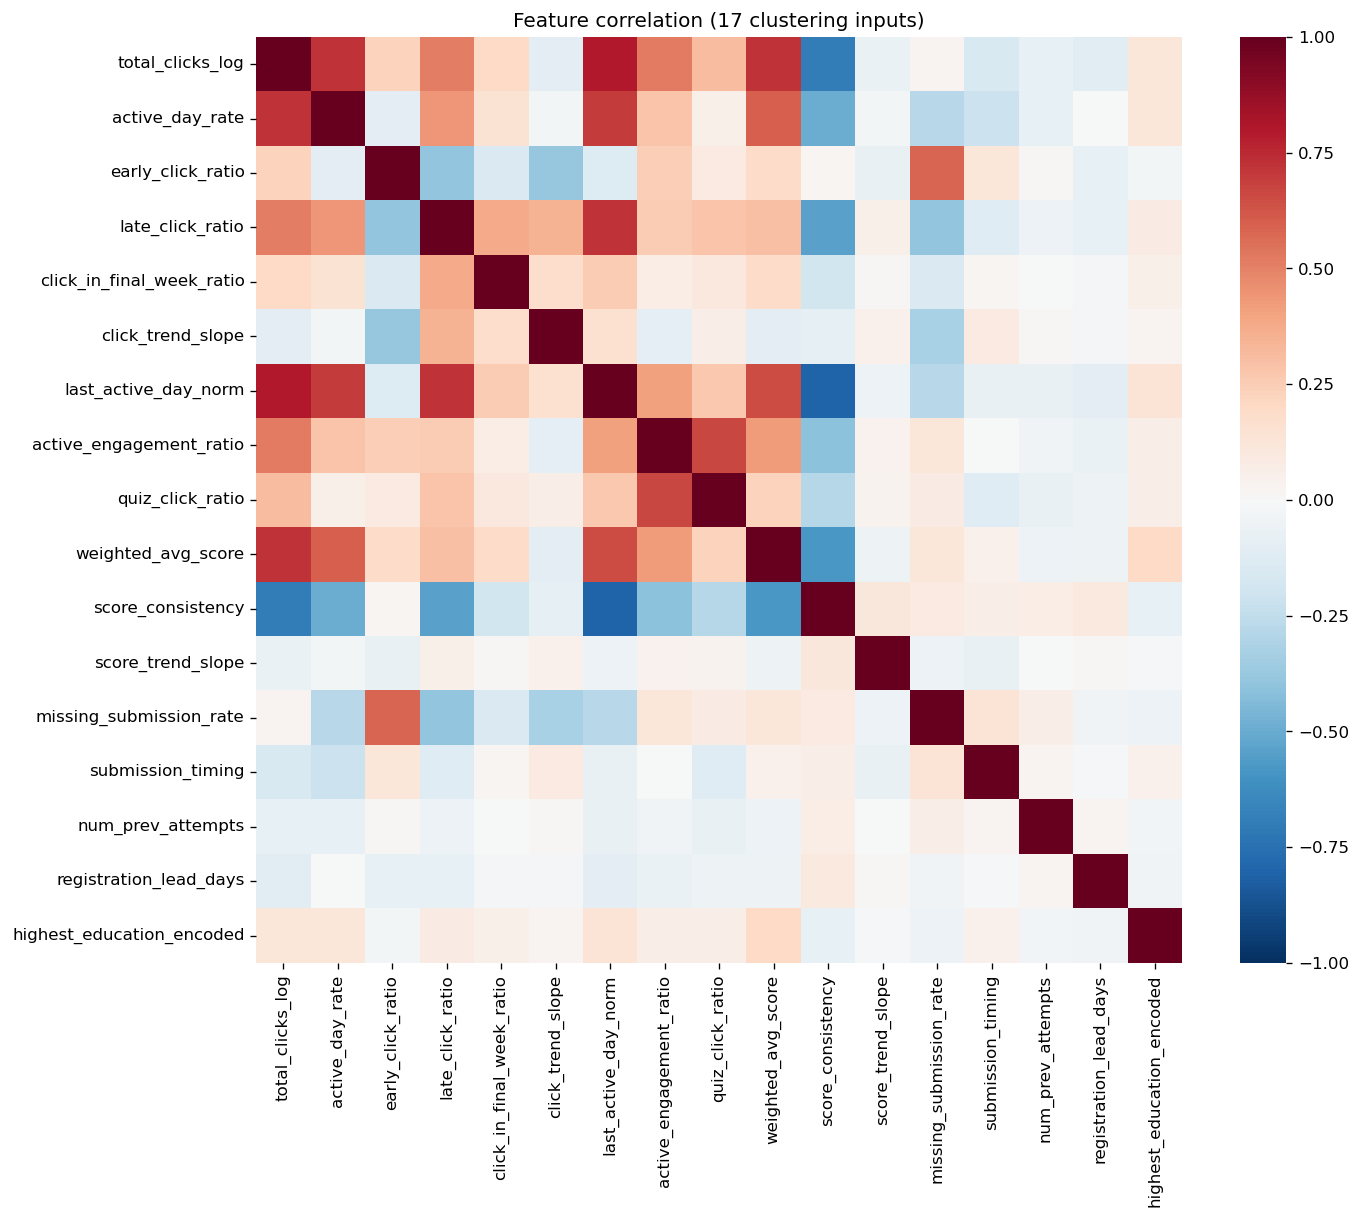

Saved feature_correlation.png


In [12]:
corr = features_df[FEATURE_COLS].corr()
high = []
for i, a in enumerate(FEATURE_COLS):
    for j, b in enumerate(FEATURE_COLS):
        if j <= i:
            continue
        r = corr.loc[a, b]
        if abs(r) > 0.70:
            high.append((a, b, r))
high.sort(key=lambda x: -abs(x[2]))
print("Pairs with |r| > 0.70:")
for a, b, r in high:
    print(f"  {a} vs {b}: {r:.3f}")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Feature correlation (17 clustering inputs)")
plt.tight_layout()
fig.savefig(FIGURES / "feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature_correlation.png")


**Interpretation**

Six pairs still exceed |r|>0.70; strongest: `last_active_day_norm` vs `score_consistency` (−0.810). These overlaps reflect real behavior — students who stop accessing the VLE early also tend to have volatile or missing scores. We keep both because one measures VLE presence and the other academic consistency. For K-Means we accept mild distance distortion in exchange for richer separation; notebook 03 metrics will show if we need to drop a feature.


## StandardScaler (mandatory for clustering)

K-Means uses Euclidean distance. Without scaling, large-range columns would dominate. EDA showed clicks from **0** to thousands while rates sit in **[0,1]**.


In [13]:
X = features_df[FEATURE_COLS].values
X_scaled, scaler = scale_features(X, MODELS)
print(f"X_scaled shape: {X_scaled.shape}")
print(f"Means near 0: {np.allclose(X_scaled.mean(axis=0), 0, atol=0.01)}")
print(f"Stds near 1:  {np.allclose(X_scaled.std(axis=0), 1, atol=0.05)}")
wide = ["total_clicks_log", "submission_timing", "click_trend_slope"]
for col in wide:
    j = FEATURE_COLS.index(col)
    print(f"  scaler {col}: mean={scaler.mean_[j]:.3f}, std={scaler.scale_[j]:.3f}")


X_scaled shape: (32593, 17)
Means near 0: True
Stds near 1:  True
  scaler total_clicks_log: mean=5.706, std=2.450
  scaler submission_timing: mean=-10.775, std=20.689
  scaler click_trend_slope: mean=-1.256, std=4.480


**Interpretation**

`X_scaled` shape **(32593, 17)**. Means≈0 check: **True**; stds≈1 check: **True**. Example scaler stats — `total_clicks_log`: mean=5.706, std=2.450; `submission_timing`: mean=-10.775, std=20.689.


## PCA visualization ONLY

**Important:** `X_pca_2d.npy` is for **2D plots only**. Notebook 03 must cluster on **`X_scaled.npy`** (all **17** features). Clustering on PCA would drop behavioural dimensions that separate subtle profiles.



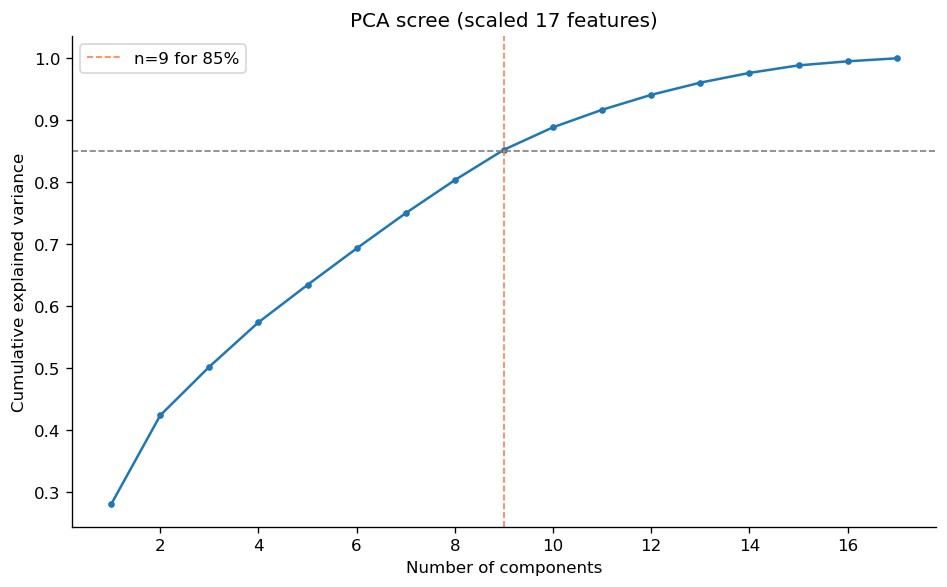

Components for 85% variance: 9


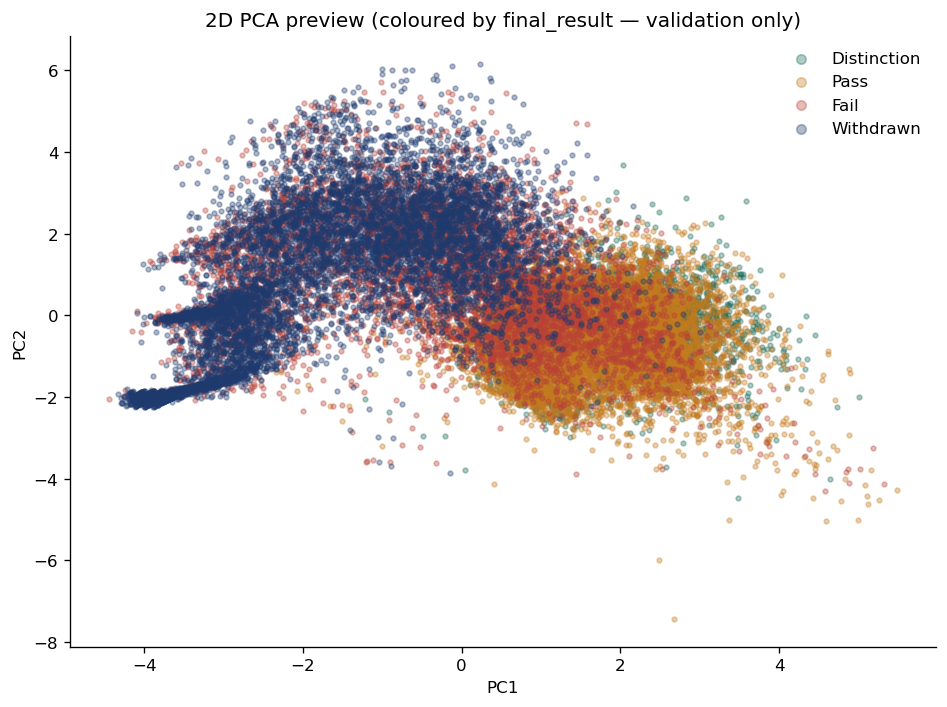

Saved scree_plot.png and pca_preview.png


In [14]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_85 = int(np.searchsorted(cumvar, 0.85) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker="o", ms=3)
ax.axhline(0.85, color="gray", ls="--", lw=1)
ax.axvline(n_85, color="coral", ls="--", lw=1, label=f"n={n_85} for 85%")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA scree (scaled 17 features)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Components for 85% variance: {n_85}")

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
joblib.dump(pca_2d, MODELS / "pca_2d.pkl")

outcome = features_df["final_result"]
fig, ax = plt.subplots(figsize=(8, 6))
for o in ["Distinction", "Pass", "Fail", "Withdrawn"]:
    m = outcome == o
    ax.scatter(X_pca_2d[m, 0], X_pca_2d[m, 1], s=8, alpha=0.35, c=PALETTE[o], label=o)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("2D PCA preview (coloured by final_result — validation only)")
ax.legend(markerscale=2, frameon=False)
plt.tight_layout()
pca_path = FIGURES / "pca_preview.png"
fig.savefig(pca_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved scree_plot.png and pca_preview.png")


**Interpretation**

**9** components explain ≥**85%** variance on scaled features. The 2D scatter is for visualization only


In [15]:
features_df.to_csv(PROCESSED / "master_features.csv", index=False)
np.save(PROCESSED / "X_scaled.npy", X_scaled)
np.save(PROCESSED / "X_pca_2d.npy", X_pca_2d)
print(f"Saved master_features.csv: {features_df.shape}")
print(f"Saved X_scaled.npy: {X_scaled.shape}")
print(f"Saved X_pca_2d.npy: {X_pca_2d.shape}")
print(f"Features: {FEATURE_COLS}")


Saved master_features.csv: (32593, 21)
Saved X_scaled.npy: (32593, 17)
Saved X_pca_2d.npy: (32593, 2)
Features: ['total_clicks_log', 'active_day_rate', 'early_click_ratio', 'late_click_ratio', 'click_in_final_week_ratio', 'click_trend_slope', 'last_active_day_norm', 'active_engagement_ratio', 'quiz_click_ratio', 'weighted_avg_score', 'score_consistency', 'score_trend_slope', 'missing_submission_rate', 'submission_timing', 'num_prev_attempts', 'registration_lead_days', 'highest_education_encoded']


## Final summary

We built **17** EDA-motivated features (dropped `weekly_click_std_log` due to **r≈0.96** with `total_clicks_log`). Strongest alignment with EDA: **missing_submission_rate**, temporal ratios + **click_trend_slope**, and **active_engagement_ratio**. Deliverables: `master_features.csv`, `X_scaled.npy`, `models/scaler.pkl`; PCA files for plots only. **`final_result` is not in X.**

The final feature matrix is **32,593 × 17** — one behavioural fingerprint per registration.


---
## Handoff to Clustering

**Files delivered:**

| File | Shape | Description |
|------|-------|-------------|
| `data/processed/master_features.csv` | 32,593 × 21 | 17 features + 4 metadata columns |
| `data/processed/X_scaled.npy` | 32,593 × 17 | Standardized feature matrix — **use this for clustering** |
| `data/processed/X_pca_2d.npy` | 32,593 × 2 | PCA projection — **visualization only** |
| `models/scaler.pkl` | — | Fitted StandardScaler — inverse-transform centroids |
| `models/pca_2d.pkl` | — | Fitted PCA(n=2) — for scatter plots |

**The 17 features in X_scaled (in order):**

| Group | Feature | What it measures |
|-------|---------|-----------------|
| A | `total_clicks_log` | Overall engagement volume (log-scaled) |
| A | `active_day_rate` | Fraction of module days with VLE activity |
| B | `early_click_ratio` | Fraction of clicks in first third of module |
| B | `late_click_ratio` | Fraction of clicks in final third of module |
| B | `click_in_final_week_ratio` | Fraction of clicks in last 7 days |
| B | `last_active_day_norm` | Normalized day of last VLE access |
| B | `click_trend_slope` | Weekly engagement trend (negative = disengaging) |
| C | `active_engagement_ratio` | (quiz+forum) / total clicks |
| C | `quiz_click_ratio` | quiz clicks / total clicks |
| D | `weighted_avg_score` | Score weighted by assessment weight |
| D | `score_consistency` | 1/(1+score_std) — higher = more consistent |
| D | `score_trend_slope` | Chronological score trend |
| D | `missing_submission_rate` | Fraction of due assessments not submitted |
| D | `submission_timing` | Mean delay vs deadline (non-submitters = global mean) |
| E | `num_prev_attempts` | Previous attempts on this module |
| E | `registration_lead_days` | Days enrolled before module start |
| E | `highest_education_encoded` | Ordinal education level 0–4 |

**Rules notebook 03 must follow:**
- Cluster on `X_scaled.npy` — never on `X_pca_2d.npy`
- `final_result` is in `master_features.csv` — never put it into X
- Use `scaler.inverse_transform(centroids)` to read cluster centers in original units
- `random_state=42` for all stochastic algorithms
---
